# Modelos de regresión lineal

![BLR](https://upload.wikimedia.org/wikipedia/commons/e/ed/Bayes_icon.svg)

Hasta ahora hemos visto modelos de regresión lineal, usando inferencia exacta para la estimación de la distribución posterior de los parámetros, bajo un caso particular (suponiendo la varianza de la dispersión conocida). Si quisiéramos asumir previas distintas a la normal para los parámetros, incluyendo una previa para el parámetro de varianza, entonces la inferencia exacta de la distribución posterior se vuelve prácticamente imposible.

En este tema, estudiamos el uso de muestreo de la distribución posterior usando técnicas Montecarlo, dándonos la libertad de elegir la previa que mejor represente nuestro conocimiento de la situación.

> **Objetivos:**
> - Revisitar modelos de predicción lineal desde una perspectiva de Montecarlo.

> **Referencias:**
> 
> - Statistical Rethinking: A Bayesian Course with Examples in R and Stan (2nd edition) - Richard McElreath.

## 1. Predicción lineal

Lo que acabamos de ver es un modelo Gaussiano para la altura de una población de adultos. Sin embargo, este modelo no tiene el componente de *regresión*.

Es común que queramos modelar como el resultado de cierta variable se relaciona con otra(s) variable(s), llamada(s) **predictor(es)**. Si el predictor tiene alguna asociación estadística con la variable de interés, la podemos usar para *predecir* dicha variable.

En este caso estudiaremos como incluir estos predictores de forma lineal en el modelo. 

Seguiremos usando los datos de los adultos en la población, pero esta vez, veremos como la altura se relaciona con el peso:

In [2]:
# Importar pandas
import pandas as pd

In [3]:
# Leer datos (separados por ;)
height_data = pd.read_csv('data/Howell1.csv', sep=';')

In [4]:
# Extraer datos de adultos
adult_height_data = height_data[height_data['age'] >= 18].copy()

In [5]:
# Algunas filas
adult_height_data.head()

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


<Axes: xlabel='weight', ylabel='height'>

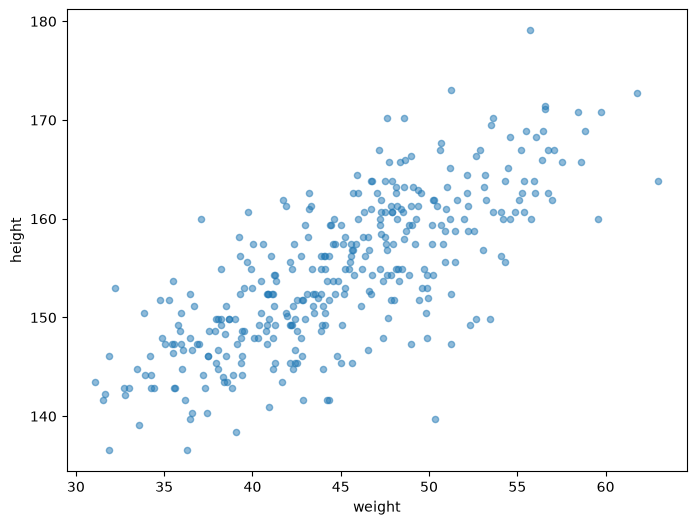

In [5]:
adult_height_data.plot(kind='scatter', x='weight', y='height', alpha=0.5, figsize=(8, 6))

Del gráfico anterior, observamos que en definitiva hay una relación marcada entre la altura y el peso. Es decir, conocer el peso de una persona nos ayuda a predecir su altura.

**¿Cómo adecuamos el modelo de la altura para incluir el peso como predictor?**

La estrategia es modificar el parámetro $\mu$ de la distribución Gaussiana, para que sea una función lineal del predictor. Ahora, para los parámetros de esta función, tendremos que declarar distribuciones previas.

De forma que, teníamos:

$$
\begin{align}
\begin{array}{lcl}
h_i & \sim & \text{Normal}(\mu, \sigma) \\
\mu & \sim & \text{Normal}(170, 20) \\
\sigma & \sim & \text{Uniform}(0, 50)
\end{array}
\end{align}
$$

Ahora, sea $w_i$ el peso de la persona $i$ y sean $\bar{w}$ el promedio de todos los pesos. De esta forma:

$$
\begin{align}
\begin{array}{lcl}
h_i & \sim & \text{Normal}(\mu_i, \sigma) \\
\mu_i & = & \alpha + \beta(w_i - \bar{w}) \\
\alpha & \sim & \text{Normal}(170, 20) \\
\beta & \sim & \text{Normal}(0, 10) \\
\sigma & \sim & \text{Uniform}(0, 50)
\end{array}
\end{align}
$$

*¿Qué significa esto?*

- Como antes, la primera expresión es la verosimilitud (probabilidad de los datos). Es casi la misma expresión, nada más notemos que cambiamos la media general $\mu$, por una media $\mu_i$ para cada observación. Es decir, la media depende de los valores específicos de cada observación.

- La segunda expresión, corresponde al modelo lineal. $\mu$ ya no es un parámetro que estimemos, sino una relación determinista (notar el símbolo $=$ en lugar de $\sim$) a los nuevos parámetros $\alpha$ y $\beta$, y que depende de la variable observada $w_i$.

  ¿Porqué incluir como predictor $w_i - \bar{w}$ en lugar de símplemente $w_i$? Algo importante cuando modelamos es poder entender los parámetros que estamos introduciendo. Notemos que de la manera en que especificamos el modelo $\mu=\alpha$ cuando $w_i=\bar{w}$; es decir, $\alpha$ es el valor esperado de la altura cuando el peso es promedio.

  ¿Y qué pasa con $\beta$? Bueno, pues el parámetro $\beta$ es el cambio esperado en la altura, cuando el peso cambia $1$ unidad (kg).

- Las demás expresiones, como antes, son las previas de nuestros parámetros, que deberemos ajustar con una debida simulación predictiva previa de ser necesario.

In [1]:
# Importart scipy.stats
from scipy import stats
# Importar numpy
import numpy as np

In [6]:
w_bar = adult_height_data['weight'].mean()
w_bar

np.float64(44.99048551988636)

In [9]:
# Simulación previa predictiva
n_samples = 1000
# Muestreamos distribuciones previas
alpha_prior = stats.norm(loc=170, scale=20)
beta_prior = stats.norm(loc=0, scale=10)
alpha_samples = alpha_prior.rvs(n_samples)
beta_samples = beta_prior.rvs(n_samples)
# Relación lineal de la altura promedio con el peso
w = np.linspace(30, 70, 100)
mu = alpha_samples[:, None] + beta_samples[:, None] * (w[None, :] - w_bar)
mu.shape

(1000, 100)

In [11]:
from matplotlib import pyplot as plt

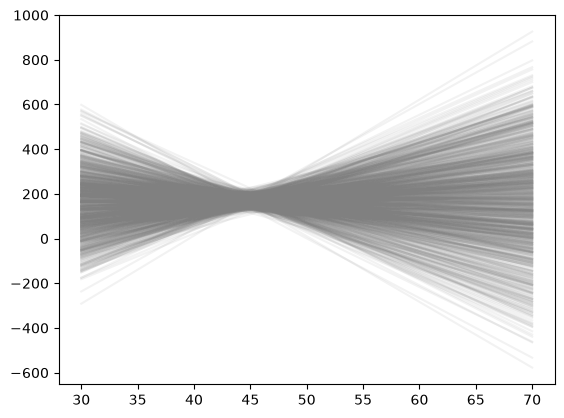

In [12]:
# Graficamos la altura promedio vs el peso
plt.plot(w, mu.T, color='gray', alpha=0.1)

Observamos que usando estas previas, las la altura promedio puede llegar a tomar valores bastante extremos para valores normales del peso. Podemos hacer algo mejor.

De la gráfica de puntos, observamos que la relación entre la altura y el peso es positiva. Una manera común de restringir un parámetro a que sea positivo es usando la distribución $\text{Log-Normal}$. Si definimos $\beta$ como $\text{Log-Normal}(0, 1)$, significa que el logaritmo de $\beta$ tiene una distribución $\text{Normal}(0, 1)$:

$$
\beta \sim \text{Log-Normal}(0, 1)
$$

In [13]:
# Densidad lognormal
help(stats.lognorm)

Help on lognorm_gen in module scipy.stats._continuous_distns:

<scipy.stats._continuous_distns.lognorm_gen object>
    A lognormal continuous random variable.

    As an instance of the `rv_continuous` class, `lognorm` object inherits from it
    a collection of generic methods (see below for the full list),
    and completes them with details specific for this particular distribution.

    Methods
    -------
    rvs(s, loc=0, scale=1, size=1, random_state=None)
        Random variates.
    pdf(x, s, loc=0, scale=1)
        Probability density function.
    logpdf(x, s, loc=0, scale=1)
        Log of the probability density function.
    cdf(x, s, loc=0, scale=1)
        Cumulative distribution function.
    logcdf(x, s, loc=0, scale=1)
        Log of the cumulative distribution function.
    sf(x, s, loc=0, scale=1)
        Survival function  (also defined as ``1 - cdf``, but `sf` is sometimes more accurate).
    logsf(x, s, loc=0, scale=1)
        Log of the survival function.
    p

In [14]:
beta_prior = stats.lognorm(s=1, scale=np.exp(0))

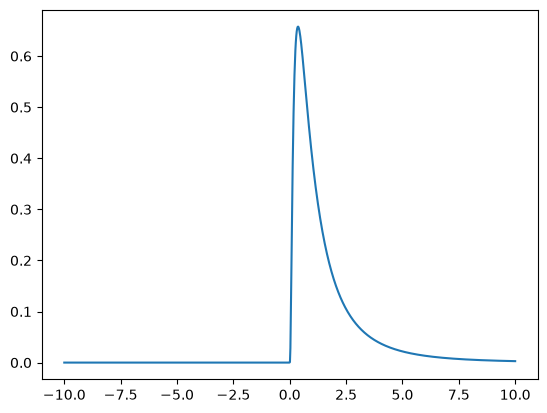

In [17]:
x = np.linspace(-10, 10, 1000)
plt.plot(x, beta_prior.pdf(x))

In [18]:
# Simulación previa predictiva
n_samples = 1000
# Muestreamos distribuciones previas
alpha_samples = alpha_prior.rvs(n_samples)
beta_samples = beta_prior.rvs(n_samples)
# Relación lineal de la altura promedio con el peso
mu = alpha_samples[:, None] + beta_samples[:, None] * (w[None, :] - w_bar)

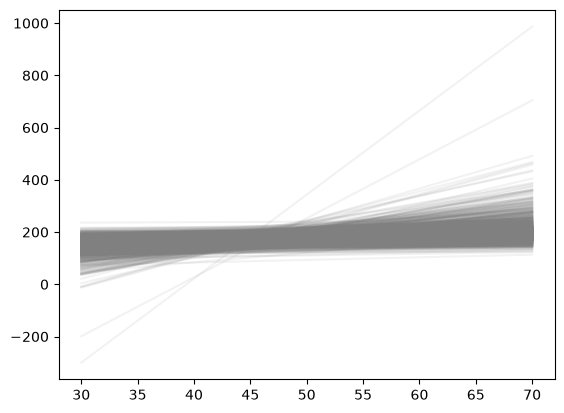

In [19]:
# Graficamos la altura promedio vs el peso
plt.plot(w, mu.T, color='gray', alpha=0.1)

¡Esto se ve mucho mejor!

De forma que nuestro modelo completo es:

$$
\begin{align}
\begin{array}{lcl}
h_i & \sim & \text{Normal}(\mu_i, \sigma) \\
\mu_i & = & \alpha + \beta(w_i - \bar{w}) \\
\alpha & \sim & \text{Normal}(170, 20) \\
\beta & \sim & \text{Log-Normal}(0, 1) \\
\sigma & \sim & \text{Uniform}(0, 50)
\end{array}
\end{align}
$$

**Estimemos la distribución posterior usando MCMC:**

In [20]:
# Importar pymc
import pymc as pm
# Importar arviz
import arviz as az
# Importar seaborn (para KDE de arrays planos)
import seaborn as sns

g++ not available, if using conda: `conda install gxx`


In [125]:
def plot_hdi_band(x, y_samples, ax=None, **kwargs):
    """Banda de credibilidad HDI sobre un eje x continuo (reemplazo manual de az.plot_hdi)."""
    ax = ax or plt.gca()
    order = np.argsort(np.asarray(x))
    hdi_da = az.hdi(y_samples, prob=0.95)
    lower = hdi_da.sel(ci_bound="lower").values
    upper = hdi_da.sel(ci_bound="upper").values
    ax.fill_between(np.asarray(x)[order], lower[order], upper[order], **kwargs)

In [126]:
# Peso
w = adult_height_data['weight'].values
# Peso promedio
w_bar = w.mean()
# Altura
height_data = adult_height_data['height'].values
# Modelo
with pm.Model() as predictive_model:
    # Sigma
    sigma = pm.Uniform("sigma", lower=0, upper=50)
    # alpha y beta
    alpha = pm.Normal("alpha", mu=170, sigma=20)
    beta = pm.Lognormal("beta", mu=0, sigma=1)
    # Mu
    mu = pm.Deterministic("mu", alpha + beta * (w - w_bar))
    # mu = alpha + beta * (w - w_bar)
    # Altura
    h = pm.Normal("h", mu=mu, sigma=sigma, observed=height_data)
    # Muestreo
    idata = pm.sample()

NUTS[nutpie]: [sigma, alpha, beta]


Output()

In [127]:
# Distribución posterior de los parámetros
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 1000, mu_dim_0: 352)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * mu_dim_0  (mu_dim_0) int64 3kB 0 1 2 3 4 5 6 ... 345 346 347 348 349 350 351
│       Data variables:
│           alpha     (chain, draw) float64 32kB 154.8 154.4 154.4 ... 155.0 154.3 154.3
│           sigma     (chain, draw) float64 32kB 5.019 4.817 4.871 ... 4.843 5.07 5.07
│           beta      (chain, draw) float64 32kB 0.8993 0.9334 0.9104 ... 0.9076 0.9076
│           mu        (chain, draw, mu_dim_0) float64 11MB 157.3 147.2 ... 162.6 161.2
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.536467+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.15789580345153809
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 2 2 1 2 2 ... 1 2 2 2 1
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.064 0.9814 ... 1.15
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.029 1.029 ... 1.069
│           mean_tree_accept          (chain, draw) float64 32kB 0.824 0.5899 ... 0.6457
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.01473 ... 0.01388
│           transformation_index      (chain, draw) int64 32kB 338 338 338 ... 338 338
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-29T02:39:25.525031+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.532936+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /observed_data
        Dimensions:  (h_dim_0: 352)
        Coordinates:
          * h_dim_0  (h_dim_0) int64 3kB 0 1 2 3 4 5 6 7 ... 345 346 347 348 349 350 351
        Data variables:
            h        (h_dim_0) float64 3kB 151.8 139.7 136.5 156.8 ... 162.6 156.2 158.8
        Attributes:
            created_at:                 2026-09-29T02:39:25.535471+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
  

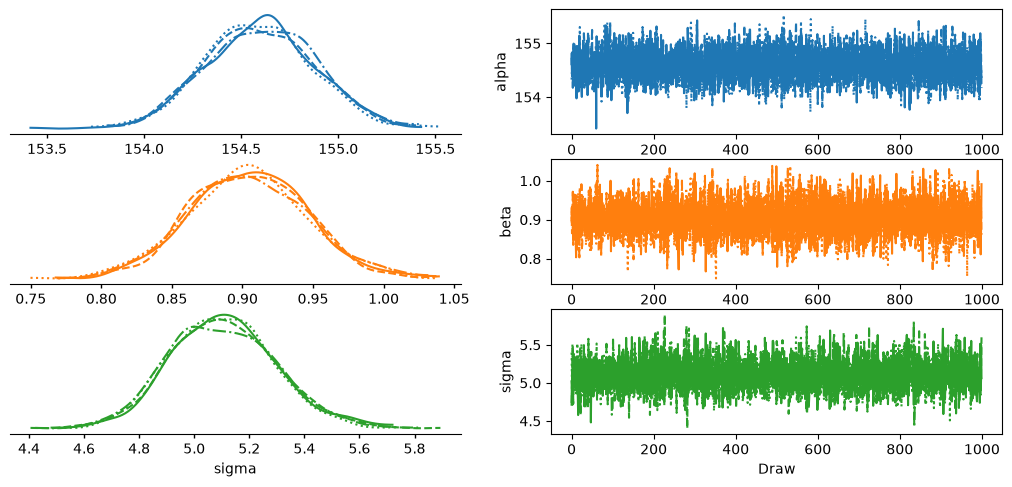

In [128]:
# az.plot_posterior
az.plot_trace_dist(idata, var_names=["alpha", "beta", "sigma"])

¿Qué podemos decir?

- La altura promedio, al peso promedio está alrededor de 155 cm.

- Por cada 1 kg adicional, se espera que la altura sea ~0.90 cm mayor.

- El 94% de la probabilidad de la distribución posterior de $\beta$ yace entre 0.82 y 0.98, lo que indica que valores cercanos a cero y valores mayores a uno, no son compatibles con los datos y el modelo.

**Predicciones con la posterior**

La idea principal de este modelo es hacer predicciones con él. Veamos como hacerlo.

Lo primero que podríamos hacer es tomar el promedio de las muestras de $\alpha$ y $\beta$, y graficar la relación promedio:

In [129]:
# Objeto de muestreo
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 1000, mu_dim_0: 352)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * mu_dim_0  (mu_dim_0) int64 3kB 0 1 2 3 4 5 6 ... 345 346 347 348 349 350 351
│       Data variables:
│           alpha     (chain, draw) float64 32kB 154.8 154.4 154.4 ... 155.0 154.3 154.3
│           sigma     (chain, draw) float64 32kB 5.019 4.817 4.871 ... 4.843 5.07 5.07
│           beta      (chain, draw) float64 32kB 0.8993 0.9334 0.9104 ... 0.9076 0.9076
│           mu        (chain, draw, mu_dim_0) float64 11MB 157.3 147.2 ... 162.6 161.2
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.536467+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.15789580345153809
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 2 2 1 2 2 ... 1 2 2 2 1
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.064 0.9814 ... 1.15
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.029 1.029 ... 1.069
│           mean_tree_accept          (chain, draw) float64 32kB 0.824 0.5899 ... 0.6457
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.01473 ... 0.01388
│           transformation_index      (chain, draw) int64 32kB 338 338 338 ... 338 338
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-29T02:39:25.525031+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.532936+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /observed_data
        Dimensions:  (h_dim_0: 352)
        Coordinates:
          * h_dim_0  (h_dim_0) int64 3kB 0 1 2 3 4 5 6 7 ... 345 346 347 348 349 350 351
        Data variables:
            h        (h_dim_0) float64 3kB 151.8 139.7 136.5 156.8 ... 162.6 156.2 158.8
        Attributes:
            created_at:                 2026-09-29T02:39:25.535471+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
  

In [130]:
mu_posterior_bar = idata.posterior["mu"].mean(dim=["chain", "draw"]).values
mu_posterior_bar

array([157.1613535 , 146.90972826, 142.73219097, 161.87710111,
       151.24103992, 170.87290226, 148.49873017, 164.08120053,
       145.44887166, 163.18418333, 159.0322751 , 151.18978179,
       146.49966325, 157.04780028, 144.52622539, 157.82770914,
       152.18931526, 148.60124642, 158.21214508, 152.54812214,
       146.01271105, 148.19118141, 145.98708198, 150.36965178,
       163.74802271, 147.83237453, 148.72939174, 156.05930378,
       149.03694049, 146.08959824, 156.77691755, 157.21261162,
       158.59658103, 158.57095197, 165.05510493, 149.29323112,
       159.0322751 , 151.21541086, 148.78064986, 152.25639181,
       154.29089843, 166.90039748, 156.16182004, 153.90646248,
       159.94072615, 163.03040895, 155.41857721, 157.34075694,
       161.13385828, 156.98195006, 155.18791564, 152.26620244,
       146.90972826, 164.49126554, 147.55045483, 157.59704757,
       147.67860015, 156.57188505, 156.6744013 , 165.95212214,
       148.21681047, 156.59751411, 152.98381621, 159.36

<Axes: xlabel='weight', ylabel='height'>

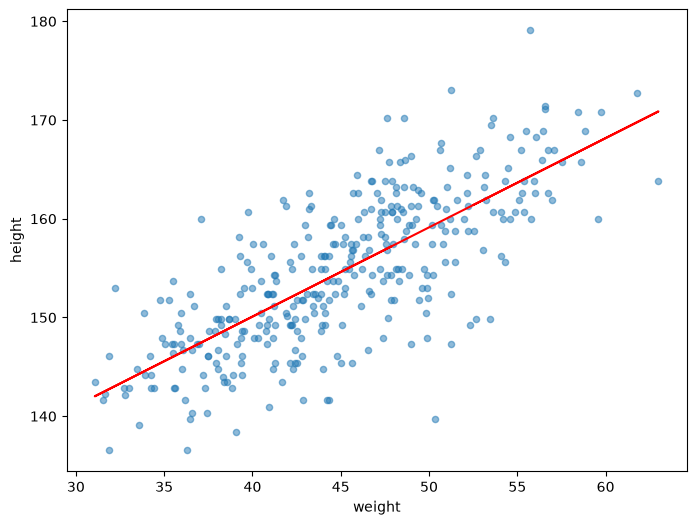

In [131]:
# Relación promedio
plt.plot(w, mu_posterior_bar, color='red', label='Relación promedio')
adult_height_data.plot(kind='scatter', x='weight', y='height', alpha=0.5, figsize=(8, 6), ax=plt.gca())

Esta relación promedio (al tratarse el modelo de una normal) no es más que la línea promedio; la línea más plausible en el conjunto infinito de lineas en la distribución posterior.

Sin embargo, a esto le podemos añadir la incertidumbre alrededor de la media, graficando algunas líneas muestreadas de la posterior:

In [132]:
# Podemos sacar algunas muestras de la distribución posterior
mu_samples = idata.posterior["mu"].sel(chain=0, draw=slice(0, 500)).values
mu_samples

array([[157.34879668, 147.15116194, 142.99562578, ..., 161.24939197,
        162.95749579, 161.5808151 ],
       [157.03394469, 146.44902916, 142.13567608, ..., 161.08267488,
        162.85564823, 161.42668464],
       [157.00666803, 146.68346907, 142.47676549, ..., 160.95529164,
        162.68442747, 161.2907956 ],
       ...,
       [157.01501429, 147.2697595 , 143.29856818, ..., 160.74257424,
        162.37490442, 161.05929502],
       [157.55047342, 145.79106278, 140.99910294, ..., 162.04844799,
        164.01814927, 162.43062883],
       [157.7896681 , 147.23699974, 142.93678739, ..., 161.82606374,
        163.59363569, 162.16902546]], shape=(501, 352))

Text(0, 0.5, 'Altura')

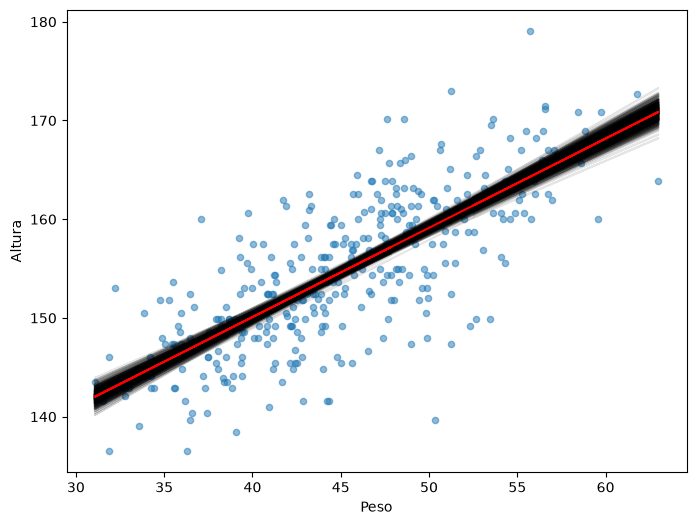

In [133]:
plt.plot(w, mu_samples.T, color='black', alpha=0.1)
plt.plot(w, mu_posterior_bar, color='red', label='Relación promedio')
adult_height_data.plot(kind='scatter', x='weight', y='height', alpha=0.5, figsize=(8, 6), ax=plt.gca())
plt.xlabel('Peso')
plt.ylabel('Altura')

Una pregunta que nos podríamos hacer es, ¿Cuánto es la altura promedio de una persona de 60kg?. Una vez más, podemos usar las muestras de la posterior para responder a esta pregunta:

In [134]:
# mu at 60
alpha_samples = idata.posterior["alpha"].values.flatten()
beta_samples = idata.posterior["beta"].values.flatten()
mu_at_60 = alpha_samples + beta_samples * (60 - w_bar)
mu_at_60

array([168.29696315, 168.39789527, 168.08964008, ..., 168.11380594,
       167.94610514, 167.94610514], shape=(4000,))

<Axes: ylabel='Density'>

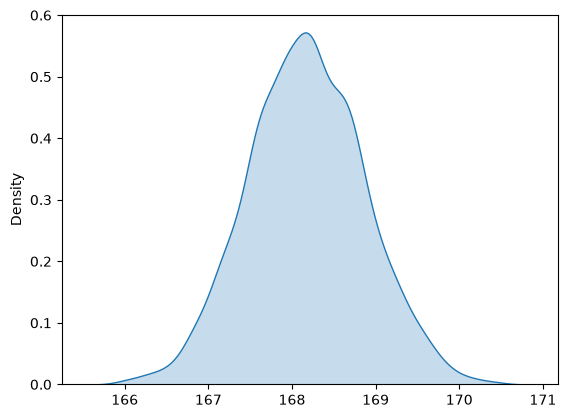

In [135]:
sns.kdeplot(mu_at_60, fill=True)

La altura promedio (89%) está entre 167 cm y 169 cm (condicional al modelo y los datos), dado que el peso es 60 kg.

**¿Y $\sigma$?**

Recordemos que el modelo de la altura era:

$$
h_i \sim \text{Normal}(\mu_i, \sigma)
$$

y aunque hasta ahora solo hemos hablado de $\mu$, la variación fuera del promedio es bastante importante.

Primero, generamos las muestras de predicción. Como antes, podríamos hacerlo a mano, pero pymc lo puede hacer por nosotros:

In [136]:
# Generamos muestras predictivas de la posterior
with predictive_model:
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [h]


Output()

In [137]:
idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:   (chain: 4, draw: 1000, mu_dim_0: 352)
│       Coordinates:
│         * chain     (chain) int64 32B 0 1 2 3
│         * draw      (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * mu_dim_0  (mu_dim_0) int64 3kB 0 1 2 3 4 5 6 ... 345 346 347 348 349 350 351
│       Data variables:
│           alpha     (chain, draw) float64 32kB 154.8 154.4 154.4 ... 155.0 154.3 154.3
│           sigma     (chain, draw) float64 32kB 5.019 4.817 4.871 ... 4.843 5.07 5.07
│           beta      (chain, draw) float64 32kB 0.8993 0.9334 0.9104 ... 0.9076 0.9076
│           mu        (chain, draw, mu_dim_0) float64 11MB 157.3 147.2 ... 162.6 161.2
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.536467+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.15789580345153809
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 2 2 1 2 2 ... 1 2 2 2 1
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.064 0.9814 ... 1.15
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 1.029 1.029 ... 1.069
│           mean_tree_accept          (chain, draw) float64 32kB 0.824 0.5899 ... 0.6457
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.01473 ... 0.01388
│           transformation_index      (chain, draw) int64 32kB 338 338 338 ... 338 338
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-29T02:39:25.525031+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Attributes:
│           created_at:                 2026-09-29T02:39:25.532936+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:  (h_dim_0: 352)
│       Coordinates:
│         * h_dim_0  (h_dim_0) int64 3kB 0 1 2 3 4 5 6 7 ... 345 346 347 348 349 350 351
│       Data variables:
│           h        (h_dim_0) float64 3kB 151.8 139.7 136.5 156.8 ... 162.6 156.2 158.8
│       Attributes:
│           created_at:                 2026-09-29T02:39:34.718687+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│ 

In [138]:
adult_height_data

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
534,162.560,47.031821,27.0,0
537,142.875,34.246196,31.0,0
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0


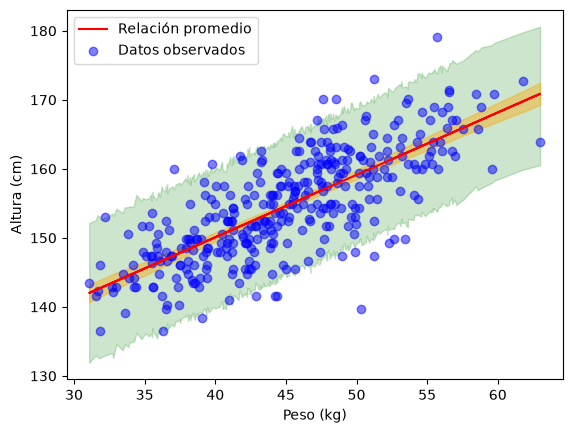

In [139]:
# Intervalo de credibilidad de la altura
plot_hdi_band(w, idata.posterior_predictive["h"], color='green', alpha=0.2)
# Intervalo de credibilidad de la altura promedio
plot_hdi_band(w, idata.posterior["mu"], color='orange', alpha=0.4)
# Línea promedio
plt.plot(w, mu_posterior_bar, color='red', label='Relación promedio')
# Nube de puntos
plt.scatter(adult_height_data["weight"], adult_height_data["height"], color='blue', alpha=0.5, label='Datos observados')
plt.xlabel('Peso (kg)')
plt.ylabel('Altura (cm)')
plt.legend()
plt.show()


## 2. Evaluación del modelo

Hasta ahorita usamos los mismos datos para visualizar las predicciones de nuestro modelo. ¿Cómo podemos hacer una evaluación real del modelo para fines predictivos?

In [140]:
# Separamos datos de entrenamiento y prueba
train_data = adult_height_data.sample(frac=0.8, random_state=42)
test_data = adult_height_data.drop(train_data.index)

In [141]:
pm.Data?

Signature:
pm.Data(
    name: str,
    value,
    *,
    dims: collections.abc.Sequence[str] | None = None,
    coords: dict[str, collections.abc.Sequence | numpy.ndarray] | None = None,
    infer_dims_and_coords=False,
    model: Optional[ForwardRef('Model')] = None,
    **kwargs,
) -> pytensor.compile.sharedvalue.SharedVariable | pytensor.tensor.variable.TensorConstant
Docstring:
Create a data container that registers a data variable with the model.

Depending on the ``mutable`` setting (default: True), the variable
is registered as a :class:`~pytensor.compile.sharedvalue.SharedVariable`,
enabling it to be altered in value and shape, but NOT in dimensionality using
:func:`pymc.set_data`.

To set the value of the data container variable, check out
:meth:`pymc.Model.set_data`.

When making predictions or doing posterior predictive sampling, the shape of the
registered data variable will most likely need to be changed.  If you encounter an
PyTensor shape mismatch error, refer to the doc

In [142]:
# Peso (entrenamiento)
w = train_data['weight'].values
# Peso promedio
w_bar = w.mean()
# Altura (entrenamiento)
height_data = train_data['height'].values
# Modelo
with pm.Model() as predictive_model:
    # Peso como variable mutable
    weight_data = pm.Data("weight", w, dims="obs")
    height_data = pm.Data("height_data", height_data, dims="obs")
    # Sigma
    sigma = pm.Uniform("sigma", lower=0, upper=50)
    # a y b
    alpha = pm.Normal("alpha", mu=170, sigma=20)
    beta = pm.Lognormal("beta", mu=0, sigma=1)
    # Mu
    mu = pm.Deterministic("mu", alpha + beta * (weight_data - w_bar), dims="obs")
    # Altura
    height = pm.Normal("height", mu=mu, sigma=sigma, observed=height_data, dims="obs")
    # Muestreo
    idata = pm.sample()

NUTS[nutpie]: [sigma, alpha, beta]


Output()

In [143]:
# Con el modelo entrenado predecimos sobre datos de prueba
w_test = test_data['weight'].values
h_test = test_data['height'].values
# Generamos muestras predictivas de la posterior
with predictive_model:
    # Actualizamos valores de w
    pm.set_data({
        "weight": w_test,
        "height_data": h_test
    })
    # Muestreo de la posterior predictiva
    test_idata = pm.sample_posterior_predictive(idata, extend_inferencedata=True)

Sampling: [height]


Output()

In [144]:
# Atributo predictions
test_idata

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:  (chain: 4, draw: 1000, obs: 282)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * obs      (obs) int64 2kB 0 1 2 3 4 5 6 7 ... 274 275 276 277 278 279 280 281
│       Data variables:
│           alpha    (chain, draw) float64 32kB 155.0 154.8 154.8 ... 154.8 155.0 154.5
│           sigma    (chain, draw) float64 32kB 4.613 5.25 4.775 ... 5.105 4.826 5.124
│           beta     (chain, draw) float64 32kB 0.9246 0.9613 0.8162 ... 0.8953 0.885
│           mu       (chain, draw, obs) float64 9MB 153.5 163.3 158.0 ... 149.7 162.6
│       Attributes:
│           created_at:                 2026-09-29T02:39:42.515389+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.11
│           sampling_time:              0.19725680351257324
│           tuning_steps:               400
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 1 2 2 2 2 ... 2 1 2 2 2
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 1.041 1.005 ... 0.9483
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 0.9918 0.9918 ... 1.047
│           mean_tree_accept          (chain, draw) float64 32kB 1.0 0.7658 ... 1.0
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 0.03962 ... 0.01398
│           transformation_index      (chain, draw) int64 32kB 338 338 338 ... 337 337
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-09-29T02:39:42.501718+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.2.0
│           creation_library_language:   Python
│           sample_dims:                 ['chain', 'draw']
│           inference_library:           nutpie
│           inference_library_version:   0.16.11
│           inference_library_settings:  {"sampler": "nuts", "adaptation": "diag", "s...
├── Group: /constant_data
│       Dimensions:  (obs: 70)
│       Coordinates:
│         * obs      (obs) int64 560B 0 1 2 3 4 5 6 7 8 9 ... 61 62 63 64 65 66 67 68 69
│       Data variables:
│           weight   (obs) float64 560B 36.49 47.7 35.49 37.9 ... 34.25 52.16 52.53
│       Attributes:
│           created_at:                 2026-09-29T02:39:43.140731+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
├── Group: /observed_data
│       Dimensions:  (obs: 70)
│       Coordinates:
│         * obs      (obs) int64 560B 0 1 2 3 4 5 6 7 8 9 ... 61 62 63 64 65 66 67 68 69
│       Data variables:
│           height   (obs) float64 560B 139.7 149.9 146.4 148.6 ... 142.9 162.6 158.8
│      

In [145]:
alpha_samples = test_idata.posterior["alpha"].values.flatten()
beta_samples = test_idata.posterior["beta"].values.flatten()
mu_samples = alpha_samples + beta_samples * (w_test[:, None] - w_bar)
mu_bar = mu_samples.mean(axis=1)
mu_bar

array([147.20731341, 157.13529588, 146.32888494, 148.46221123,
       164.97666651, 154.0590555 , 161.13667919, 157.07081026,
       155.31395331, 147.20731341, 164.42451147, 147.83476232,
       156.76963478, 164.22372782, 165.42842972, 154.76179827,
       152.32729651, 161.11158123, 152.55317811, 159.0033529 ,
       149.69201109, 147.5586848 , 154.15944732, 158.15002238,
       156.11708792, 150.67083139, 149.13985605, 163.24390093,
       154.73670032, 157.77355304, 152.20180673, 159.35472429,
       151.34847621, 147.30770524, 157.52257347, 147.40809706,
       164.97666651, 154.23474119, 150.74612526, 145.3751626 ,
       147.73437049, 159.70609567, 144.64732186, 150.29436204,
       153.80807593, 152.55295679, 151.04730073, 157.02061434,
       153.45670454, 142.94066083, 164.29902169, 158.17512034,
       156.14218587, 155.89586877, 158.60178559, 150.99710482,
       154.58611258, 157.59786734, 157.82374895, 145.17437895,
       155.74061857, 154.93748397, 160.28334867, 153.23

In [146]:
order = np.argsort(w_test)
lower, upper = np.percentile(mu_samples, [2.5, 97.5], axis=1)


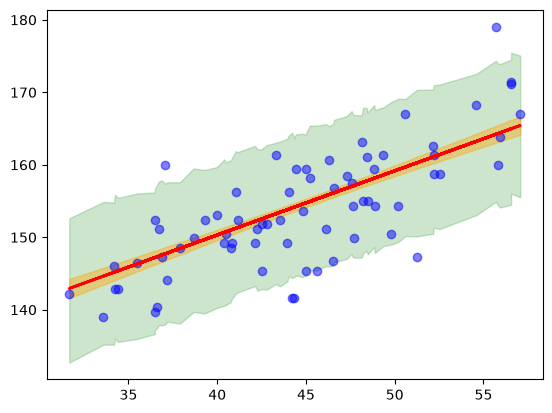

In [147]:
# Intervalo de credibilidad de la altura
plot_hdi_band(w_test, test_idata.posterior_predictive["height"], color='green', alpha=0.2)
# Intervalo de credibilidad de la altura promedio
plt.fill_between(w_test[order], lower[order], upper[order], color='orange', alpha=0.4)
# Línea promedio
plt.plot(w_test, mu_bar, color='red', linewidth=2)
# Nube de puntos
plt.scatter(test_data["weight"], test_data["height"], color='blue', alpha=0.5, label='Datos de prueba')

In [148]:
# Importamos sklearn.metrics.r2_score, mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error

In [149]:
# R2
r2_score(test_data['height'],  mu_bar)

0.5568385104972144

In [150]:
# MSE
mean_squared_error(test_data['height'], mu_bar)

29.684887963679156

In [153]:
# % entre lower y upper de hdi
hdi_height = az.hdi(test_idata.posterior_predictive["height"], prob=0.95)
lower = hdi_height.sel(ci_bound="lower").values
higher = hdi_height.sel(ci_bound="upper").values
((lower <= test_data['height'].values) & (test_data['height'].values <= higher)).mean()

np.float64(0.9285714285714286)

c:\Users\esjim\OneDrive\Documentos\ITESO\mgp2026\.venv\Lib\site-packages\arviz_stats\accessors.py:484: UserWarning: Computing <bound method BaseDataArray.hdi of <arviz_stats.base.dataarray.BaseDataArray object at 0x00000288274D6300>> on DataTree named posterior_predictive which doesn't match the group argument posterior
  warnings.warn(


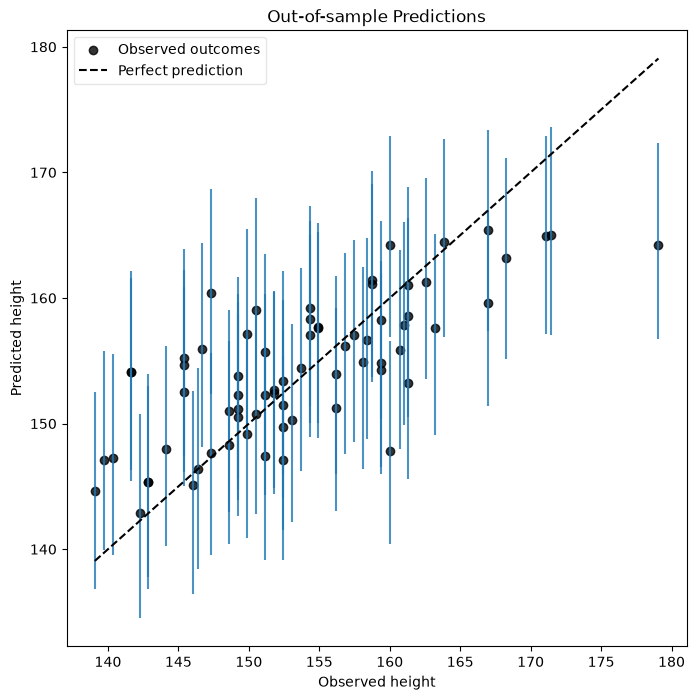

In [154]:
# Gráfica posterior predictiva para problemas de regresión
_, ax = plt.subplots(figsize=(8, 8))

model_preds = test_idata.posterior_predictive
hdi_height = az.hdi(model_preds)["height"]

# uncertainty about the estimates:
ax.vlines(
    test_data["height"].values,
    hdi_height.sel(ci_bound="lower"),
    hdi_height.sel(ci_bound="upper"),
    alpha=0.8,
)

# actual outcomes:
ax.scatter(
    x=test_data["height"].values,
    y=model_preds["height"].mean(("chain", "draw")),
    marker="o",
    color="k",
    alpha=0.8,
    label="Observed outcomes",
)

x_min = test_data["height"].min()
x_max = test_data["height"].max()
ax.plot([x_min, x_max], [x_min, x_max], linestyle="--", color="k", label="Perfect prediction")
ax.set_xlabel("Observed height")
ax.set_ylabel("Predicted height")
ax.set_title("Out-of-sample Predictions")
ax.legend(fontsize=10, frameon=True, framealpha=0.5);

La anterior gráfica fue adaptada de: https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/posterior_predictive.html

## 3. Comentarios finales

Como en la clase 3, podemos usar este mismo tipo de modelos lineales en los parámetros para representar relaciones no lineales entre los datos. Podemos usar polinomios, o cualquier otro tipo de representaciones no lineales que nos interese.

Por ejemplo, si consideraramos todos los datos, incluyendo los de los niños:

In [156]:
height_data = pd.read_csv('data/Howell1.csv', sep=';')

Text(0, 0.5, 'Height (cm)')

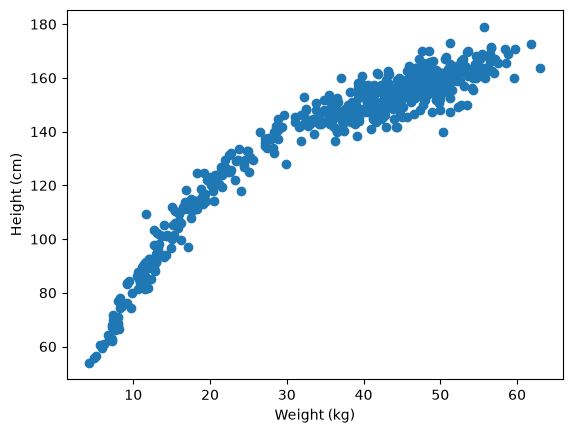

In [157]:
# Scatter plot
plt.scatter(height_data["weight"], height_data["height"])
plt.xlabel("Weight (kg)")
plt.ylabel("Height (cm)")

Observamos una relación cúbica. **Tarea**

**Ayuda**. Estandarizar el peso antes.

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>